# 손실 함수
- 경사하강법의 기술적 표현: 어떤 손실 함수(loss function)이 정의 되었을 때 손실 함수의 값이 최소가 되는 지점을 찾아가는 방법
- 제곱오차: 손실 함수 중 하나. 함수의 최소값을 알아내려면 기울기에 따라 함수의 값이 낮은 쪽으로 이동해야 한다.  
    $SE = (y_i - \hat{y}_i)^2$  
- 손실 함수를 가중치나 절편에 대해 편미분한 다음, 변화율에서 빼는 방법을 쓴다.  
 
    $w = w - \alpha \frac{\partial SE}{\partial w}$  
    $b = b - \alpha \frac{\partial SE}{\partial b}$

# 선형 회귀를 위한 뉴런
- 정방향 계산 == $\hat{y}$을 구함
- 역방향 계산 == 그래디언트(변화율)을 구함.  

<img src="img/p.png" alt="image.png" style="width:500px;" />

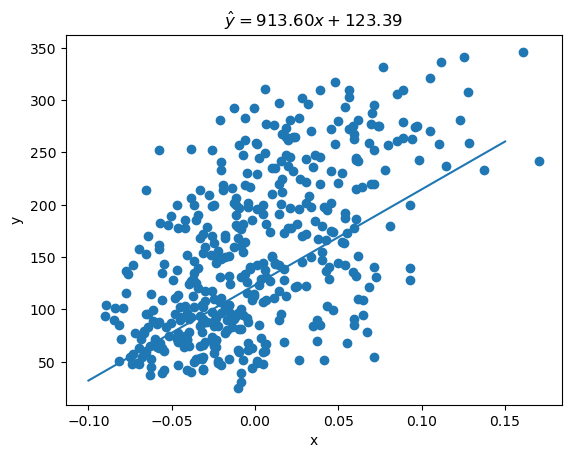

In [13]:
from sklearn import datasets
import matplotlib.pyplot as plt

class Neuron:
    def __init__(self):
        self.w = 1.0
        self.b = 1.0
    
    def forpass(self, x): # 정방향 계산
        y_hat = x * self.w + self.b
        return y_hat

    def backprob(self, x, err): # 역방향 계산
        w_grad = x*err
        b_grad = 1 * err
        return w_grad, b_grad

    def fit(self, x, y, epochs=1000): # 훈련
        for i in range(epochs):
            for x_i, y_i in zip(x, y):
                y_hat = self.forpass(x_i)
                err = -(y_i - y_hat)
                w_grad, b_grad = self.backprob(x_i, err);
                self.w -= w_grad
                self.b -= b_grad # 빼는 이유: 손실 함수의 낮은 쪽으로 이동하기 위하여


diabetes = datasets.load_diabetes()

x = diabetes.data[:,2]
y = diabetes.target

neuron = Neuron()
neuron.fit(x, y)

plt.scatter(x, y)
pt1 = (-0.1, neuron.forpass(-0.1))
pt2 = (0.15, neuron.forpass(0.15))
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]])

plt.title(rf'$\hat y = {neuron.w:.2f}x + {neuron.b:.2f}$')

plt.xlabel('x')
plt.ylabel('y')

plt.show()

# 퍼센트론
- 초기 인공지능 알고리즘.
    - 1957년 코넬 항공 연구소(Cornell Aeronautical Laboratory)의 프랭크 로젠블랫(Frank Rosenblatt)이 이진 분류 문제에서 최적의 가중치르 학습하는 퍼셉트론(Perceptron) 알고리즘 발표

    <img src="img/q.png" alt="image.png" style="width:500px;" />

- 계단 함수 $y = \begin{cases} 1 & z > 0 \\ -1 & z \le 0 \end{cases}$

- 여러개의 특성을 사용하기 위해서 $z = w_1 x_1 + w_2 x_2 + ... + w_n x_n + b$로 표현한다. ($w_i$는 가중치, $x_i$는 각 특성의 입력값, $b$는 절편)  
    또는 $z = \sum_{i=1}^{n} w_i x_i + b$

- 단층 퍼셉트론(Single-layer Perceptron): 값을 보내는 단계와 값을 받아 출력하는 두 단계로 구성. XOR 게이트를 구현할 수 없음.  
<img src="img/r.png" alt="image.png" style="width:250px;" />
<img src="img/s.png" alt="image.png" style="width:500px;" />
- 다층 퍼셉트론(Multi-layer Perceptron, MLP): 여러 개의 층을 가진 퍼셉트론.
    - XOR 게이트를 구현할 수 있음(AND, NAND, OR 게이트의 조합).
    - 은닉층(hidden layer): 입력층과 출력층 사이에 존재하는 층  
    <img src="img/t.png" alt="image.png" style="width:250px;" />
    - 심층 신경망(Deep Neural Network, DNN): 2개 이상의 은닉층을 가진 신경망.  
    <img src="img/u.png" alt="image.png" style="width:250px;" />

    
- 적응형 선형 뉴런(Adaptive Linear Neuron, Adaline(아달린)): 퍼셉트론 이후 1960년대에 스탠포드 대학의 버나드 위드로우(Bernard Widrow)와 테드 호프(Tedd Hoff)가 퍼셉트론의 학습 알고리즘을 개선히여 발표.
    <img src="img/v.png" alt="image.png" style="width:500px;" />
    - 퍼셉트론과 달리 역방향 계산을 계단함수 전에 함

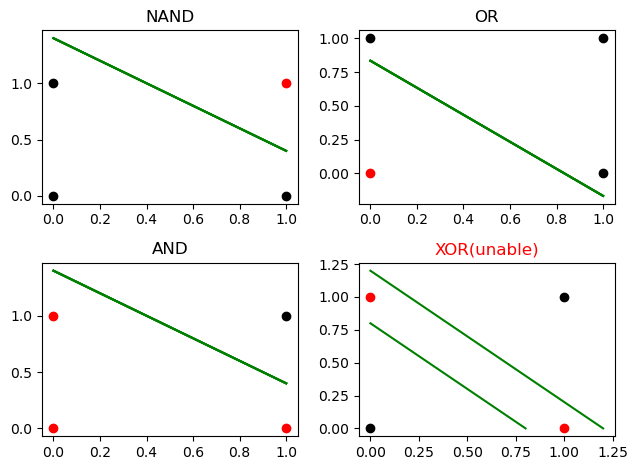

In [76]:
# 단층 퍼셉트론의 예시

class Gate:
    def __init__(self, w1, w2, b, ax):
        self.ax = ax
        self.w1 = w1
        self.w2 = w2
        self.b = b

    def scatter(self, x1, x2):
        result = x1*self.w1 + x2*self.w2 + self.b
        self.ax.scatter([x1], [x2], color='k' if result > 0 else 'r')

    def plot(self):
        self.ax.plot([0, 1], [-(0*self.w1 + self.b)/self.w2, -(1*self.w1 + self.b)/self.w2], color='g')

fig = plt.figure()

gates = [
    Gate(-0.5, -0.5, 0.7, fig.add_subplot(2, 2, 1, title='NAND')),
    Gate(0.6, 0.6, -0.5, fig.add_subplot(2, 2, 2, title='OR')),
    Gate(0.5, 0.5, -0.7, fig.add_subplot(2, 2, 3, title='AND'))
]
    
test = ((0, 0), (0, 1), (1, 0), (1, 1))

for point in test:
    for gate in gates:
        gate.scatter(point[0], point[1])
        gate.plot()


ax = fig.add_subplot(2, 2, 4, title='XOR(unable)')
ax.title.set_color('red')
for point in test:
    ax.scatter([point[0]], [point[1]], color='k' if point[0] == point[1] else 'r')

ax.plot([0, 0.8], [0.8, 0], color='g')
ax.plot([0, 1.2], [1.2, 0], color='g')


plt.tight_layout()
plt.show()
